In [1]:
print("""
=========================================================
CERN Dielectron Dataset

Notebook 5 : Feature Selection

Objectives
----------
1. Rank features using multiple feature selection techniques.
2. Compare linear and non-linear feature importance.
3. Generate a consensus feature ranking.
4. Save rankings for model training.

NOTE:
No feature is removed in this notebook.
Model Training (Notebook 6) will determine the optimal feature subset.

Author : Ivy Singh
=========================================================
""")


CERN Dielectron Dataset

Notebook 5 : Feature Selection

Objectives
----------
1. Rank features using multiple feature selection techniques.
2. Compare linear and non-linear feature importance.
3. Generate a consensus feature ranking.
4. Save rankings for model training.

NOTE:
No feature is removed in this notebook.
Model Training (Notebook 6) will determine the optimal feature subset.

Author : Ivy Singh



In [2]:
# =====================================================
# Import Required Libraries
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Selection
from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_regression
)

# Models
from sklearn.ensemble import RandomForestRegressor

# Feature Importance
from sklearn.inspection import permutation_importance

# Explainability
import shap

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# =====================================================
# Load Engineered Dataset
# =====================================================

df = pd.read_csv("../data/processed/dielectron_engineered.csv")

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")

print("\nDataset Shape :", df.shape)

Dataset Loaded Successfully

Dataset Shape : (99977, 31)


In [4]:
# =====================================================
# Dataset Overview
# =====================================================

print("="*60)

print("First Five Rows")

print("="*60)

display(df.head())

print("\n")

print("="*60)

print("Dataset Information")

print("="*60)

display(df.info())

print("\n")

print("="*60)

print("Summary Statistics")

print("="*60)

display(df.describe().T)

First Five Rows


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M,Total_Energy,Energy_Difference,Energy_Ratio,Momentum1,Momentum2,Total_Momentum,Momentum_Difference,Total_PT,PT_Difference,PT_Ratio,Eta_Difference,Phi_Difference,Total_Charge,Charge_Product
0,58.7141,-7.3113,10.5310,-57.2974,12.8202,-2.2027,2.1777,1,11.2836,-1.0323,-1.8807,-11.0778,2.1454,-2.3440,-2.0728,-1,8.9484,69.9977,47.4305,5.2035,58.7141,11.2836,69.9978,47.4305,14.9656,10.6748,5.9758,0.1414,4.2505,0,-1
1,6.6119,-4.1521,-0.5799,-5.1128,4.1924,-1.0284,-3.0028,-1,17.1492,-11.7135,5.0447,11.4647,12.7536,0.8081,2.7349,1,15.8930,23.7611,10.5373,0.3856,6.6119,17.1492,23.7611,10.5373,16.9460,8.5612,0.3287,1.8365,5.7378,0,-1
2,25.5419,-11.4809,2.0417,22.7246,11.6610,1.4205,2.9656,1,15.8203,-1.4728,2.2590,-15.5888,2.6967,-2.4551,2.1486,1,38.3877,41.3622,9.7216,1.6145,25.5419,15.8203,41.3622,9.7215,14.3577,8.9643,4.3242,3.8756,0.8170,2,1
3,65.3959,7.5121,11.8871,63.8662,14.0619,2.2184,1.0072,1,25.1273,4.0879,2.5964,24.6563,4.8427,2.3302,0.5659,-1,3.7286,90.5232,40.2686,2.6026,65.3959,25.1274,90.5233,40.2685,18.9046,9.2192,2.9037,0.1118,0.4413,0,-1
4,61.4504,2.9528,-14.6227,-59.6121,14.9179,-2.0938,-1.3715,-1,13.8871,-0.2778,-2.4256,-13.6708,2.4415,-2.4237,-1.6848,-1,2.7472,75.3375,47.5633,4.4250,61.4503,13.8871,75.3374,47.5632,17.3593,12.4764,6.1103,0.3300,0.3133,-2,1




Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 99977 entries, 0 to 99976
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   E1                   99977 non-null  float64
 1   px1                  99977 non-null  float64
 2   py1                  99977 non-null  float64
 3   pz1                  99977 non-null  float64
 4   pt1                  99977 non-null  float64
 5   eta1                 99977 non-null  float64
 6   phi1                 99977 non-null  float64
 7   Q1                   99977 non-null  int64  
 8   E2                   99977 non-null  float64
 9   px2                  99977 non-null  float64
 10  py2                  99977 non-null  float64
 11  pz2                  99977 non-null  float64
 12  pt2                  99977 non-null  float64
 13  eta2                 99977 non-null  float64
 14  phi2                 99977 non-null  float64
 15  Q2                   9997

None



Summary Statistics


,count,mean,std,min,25%,50%,75%,max
E1,99977.0000,36.4360,41.2142,0.3779,8.4573,21.7171,50.0181,850.6020
px1,99977.0000,0.1364,13.4046,-250.5870,-5.2332,0.1412,5.7150,134.5390
py1,99977.0000,0.1825,13.4707,-126.0790,-5.2774,0.0989,5.6480,147.4670
pz1,99977.0000,-1.5113,51.6017,-840.9870,-15.8618,-0.3135,13.2098,760.0960
pt1,99977.0000,14.4119,12.3891,0.2196,3.7706,12.9675,20.0190,265.5780
eta1,99977.0000,-0.0642,1.4622,-4.1654,-1.2839,-0.0613,1.1444,2.6230
phi1,99977.0000,0.0216,1.7996,-3.1416,-1.5272,0.0344,1.5623,3.1414
Q1,99977.0000,-0.0055,1.0000,-1.0000,-1.0000,-1.0000,1.0000,1.0000
E2,99977.0000,44.0050,46.7528,0.4725,11.0572,25.2652,66.9268,948.3750
px2,99977.0000,-0.0034,13.1280,-233.7300,-4.7946,-0.0350,4.8201,227.3300


In [5]:
# =====================================================
# Separate Features and Target
# =====================================================

# Predictor Variables
X = df.drop(columns=["M"])

# Target Variable
y = df["M"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

print("\nTotal Features :", X.shape[1])

Feature Matrix Shape : (99977, 30)
Target Shape : (99977,)

Total Features : 30


In [6]:
# =====================================================
# Feature Importance using Correlation
# =====================================================
# Measures linear relationship between each feature
# and the target variable (Invariant Mass).
#
# Range:
# -1  -> Strong Negative Correlation
#  0  -> No Correlation
# +1  -> Strong Positive Correlation
# =====================================================

correlation_scores = (
    df.corr(numeric_only=True)["M"]
      .drop("M")
      .abs()
      .sort_values(ascending=False)
)

correlation_df = pd.DataFrame({
    "Feature": correlation_scores.index,
    "Correlation": correlation_scores.values
})

display(correlation_df)

,Feature,Correlation
0,Total_PT,0.6283
1,Eta_Difference,0.5306
2,Total_Momentum,0.4697
3,Total_Energy,0.4697
4,pt1,0.4373
5,pt2,0.4372
6,Momentum2,0.3248
7,E2,0.3248
8,Momentum1,0.2854
9,E1,0.2854


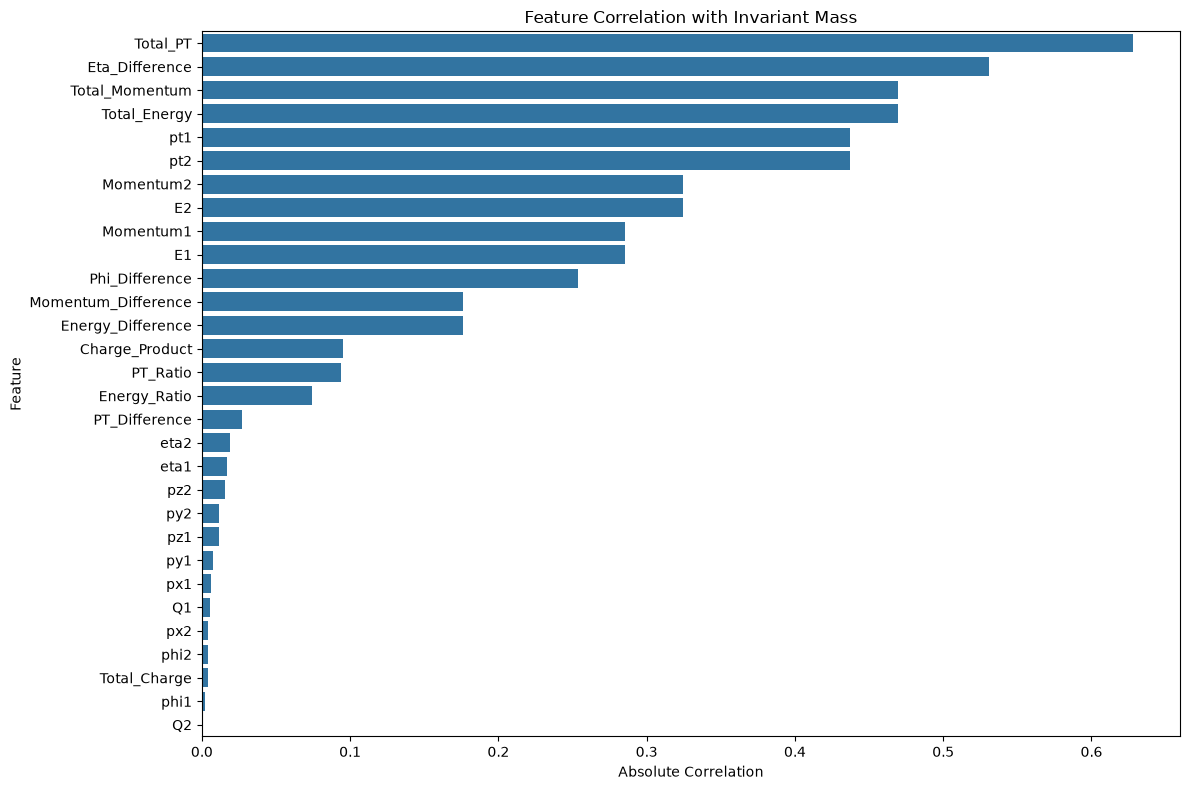

In [7]:
# =====================================================
# Visualize Correlation Scores
# =====================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=correlation_df,
    y="Feature",
    x="Correlation"
)

plt.title("Feature Correlation with Invariant Mass")

plt.xlabel("Absolute Correlation")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [8]:
# =====================================================
# Feature Variance Analysis
# =====================================================
# Features with extremely low variance generally
# contribute little information to the model.
#
# NOTE:
# We DO NOT remove any feature here.
# We simply record the variance.
# =====================================================

variance = X.var()

variance = variance.sort_values(ascending=False)

variance_df = pd.DataFrame({

    "Feature": variance.index,

    "Variance": variance.values

})

display(variance_df)

,Feature,Variance
0,pz2,3773.9545
1,Total_Energy,3291.3562
2,Total_Momentum,3291.3561
3,pz1,2662.7319
4,Momentum2,2185.8202
5,E2,2185.8201
6,Momentum_Difference,2084.5062
7,Energy_Difference,2084.5062
8,E1,1698.6104
9,Momentum1,1698.6104


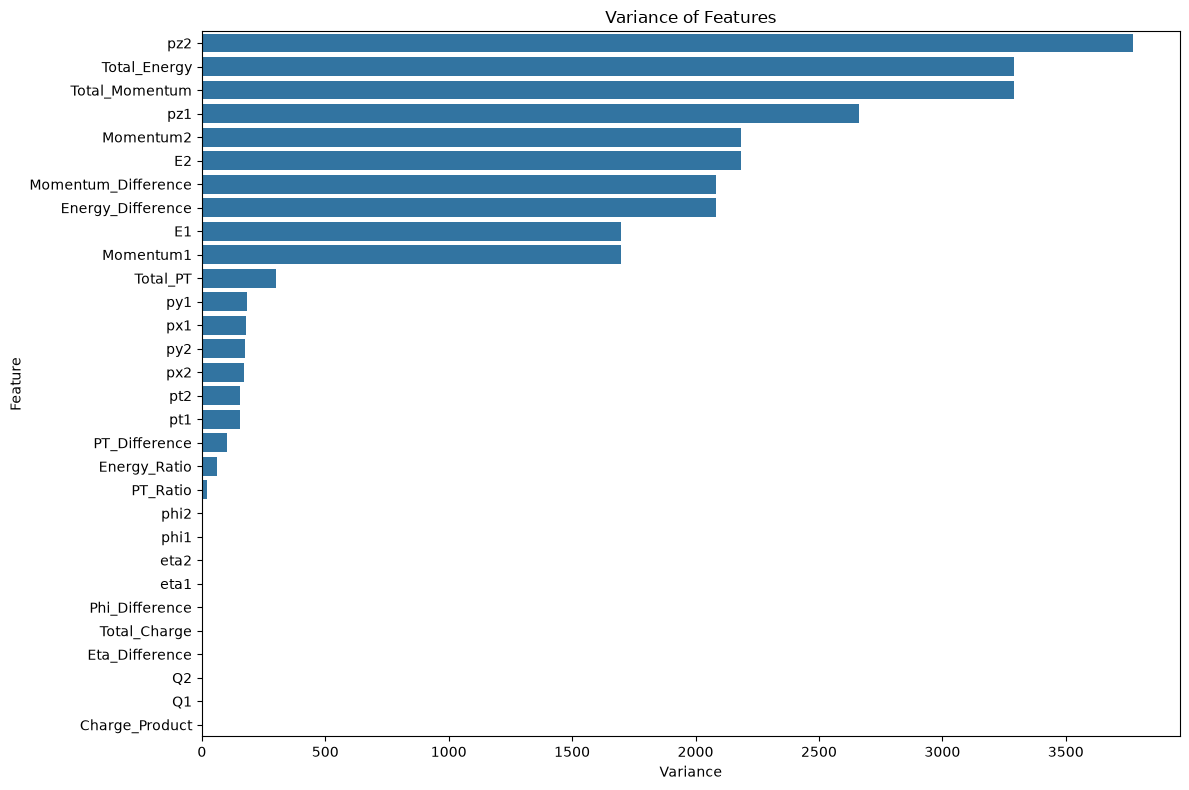

In [9]:
# =====================================================
# Visualize Feature Variance
# =====================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=variance_df,
    y="Feature",
    x="Variance"
)

plt.title("Variance of Features")

plt.xlabel("Variance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [10]:
# =====================================================
# Mutual Information Analysis
# =====================================================
# Mutual Information measures both linear and
# non-linear dependency between a feature and target.
#
# Higher MI Score
# ---------------
# More useful feature
#
# Lower MI Score
# --------------
# Less useful feature
# =====================================================

mi_scores = mutual_info_regression(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi_scores
})

mi_df = mi_df.sort_values(
    by="Mutual Information",
    ascending=False
)

display(mi_df)

,Feature,Mutual Information
26,Eta_Difference,0.3836
21,Total_Momentum,0.3278
16,Total_Energy,0.3278
23,Total_PT,0.2785
27,Phi_Difference,0.2581
12,pt2,0.1514
4,pt1,0.1408
19,Momentum1,0.1072
0,E1,0.1072
20,Momentum2,0.1057


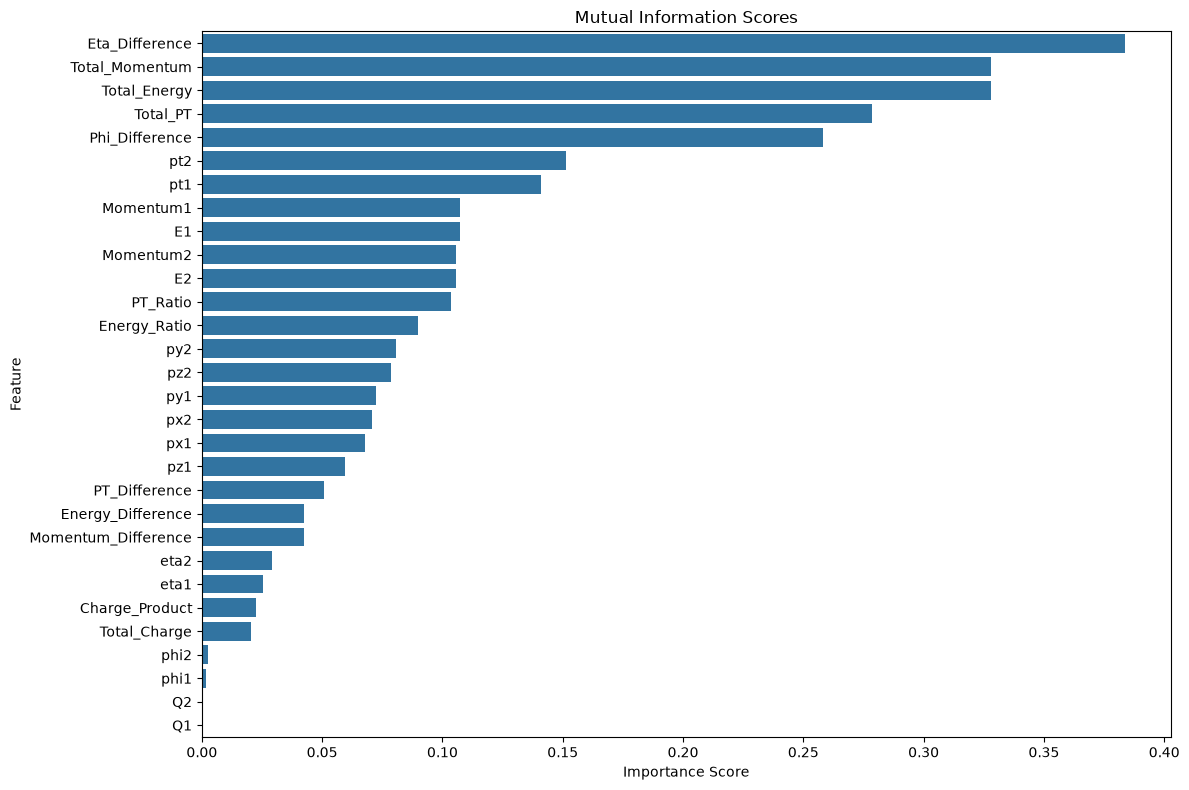

In [11]:
# =====================================================
# Visualize Mutual Information Scores
# =====================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=mi_df,
    y="Feature",
    x="Mutual Information"
)

plt.title("Mutual Information Scores")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [12]:
# =====================================================
# Random Forest Feature Importance
# =====================================================
# Random Forest estimates feature importance based
# on the reduction in prediction error achieved
# when splitting on each feature.
#
# Higher Importance
# -----------------
# Greater contribution to prediction.
# =====================================================

rf = RandomForestRegressor(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf.fit(X, y)

rf_df = pd.DataFrame({

    "Feature": X.columns,

    "Random Forest": rf.feature_importances_

})

rf_df = rf_df.sort_values(

    by="Random Forest",

    ascending=False

)

display(rf_df)

,Feature,Random Forest
23,Total_PT,0.3787
26,Eta_Difference,0.3540
24,PT_Difference,0.0476
27,Phi_Difference,0.0467
21,Total_Momentum,0.0406
16,Total_Energy,0.0391
0,E1,0.0259
19,Momentum1,0.0256
20,Momentum2,0.0156
8,E2,0.0153


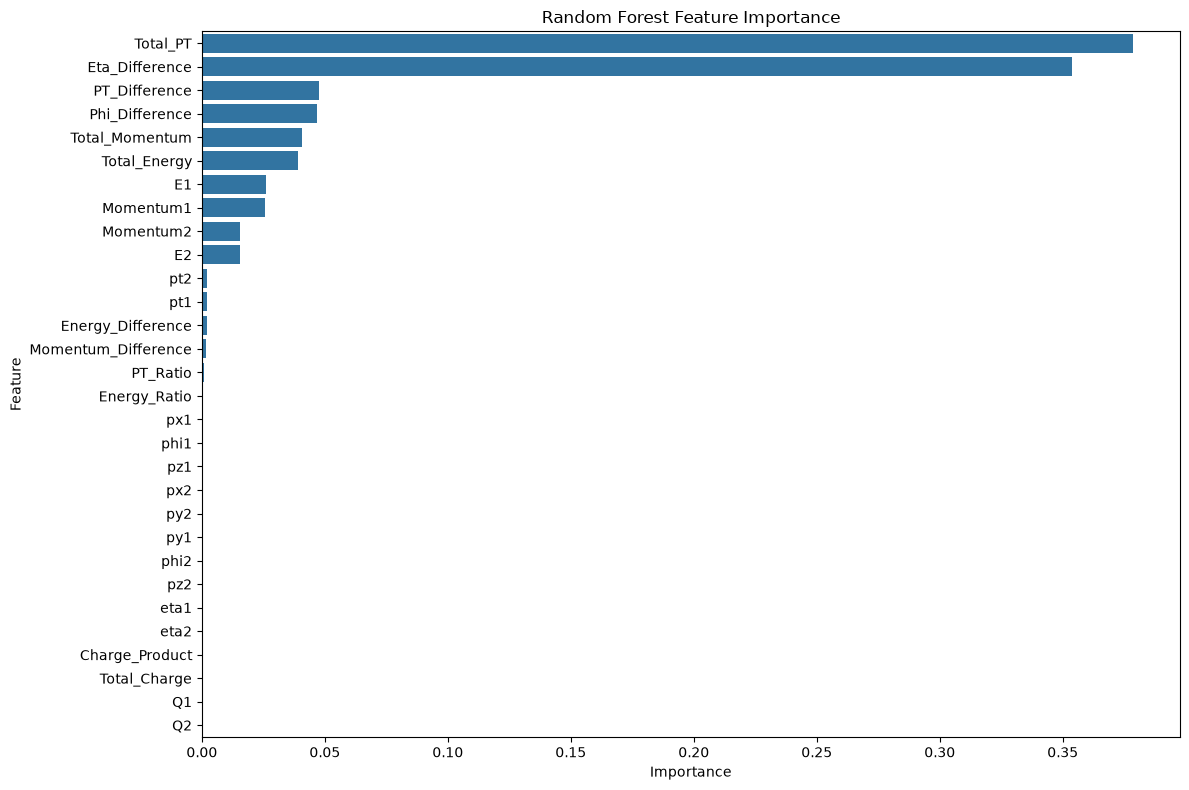

In [13]:
# =====================================================
# Visualize Random Forest Feature Importance
# =====================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=rf_df,
    y="Feature",
    x="Random Forest"
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [15]:
# =====================================================
# Permutation Importance
# =====================================================
# Measures the drop in model performance after
# randomly shuffling each feature.
#
# Larger drop
# -----------
# More important feature
# =====================================================

perm = permutation_importance(

    rf,

    X,

    y,

    n_repeats=10,

    random_state=42,

    scoring="r2",

    n_jobs=1

)

perm_df = pd.DataFrame({

    "Feature": X.columns,

    "Permutation": perm.importances_mean

})

perm_df = perm_df.sort_values(

    by="Permutation",

    ascending=False

)

display(perm_df)

,Feature,Permutation
23,Total_PT,0.8848
26,Eta_Difference,0.8219
27,Phi_Difference,0.1097
21,Total_Momentum,0.0689
24,PT_Difference,0.0678
16,Total_Energy,0.0662
19,Momentum1,0.0378
0,E1,0.0369
20,Momentum2,0.0232
8,E2,0.0224


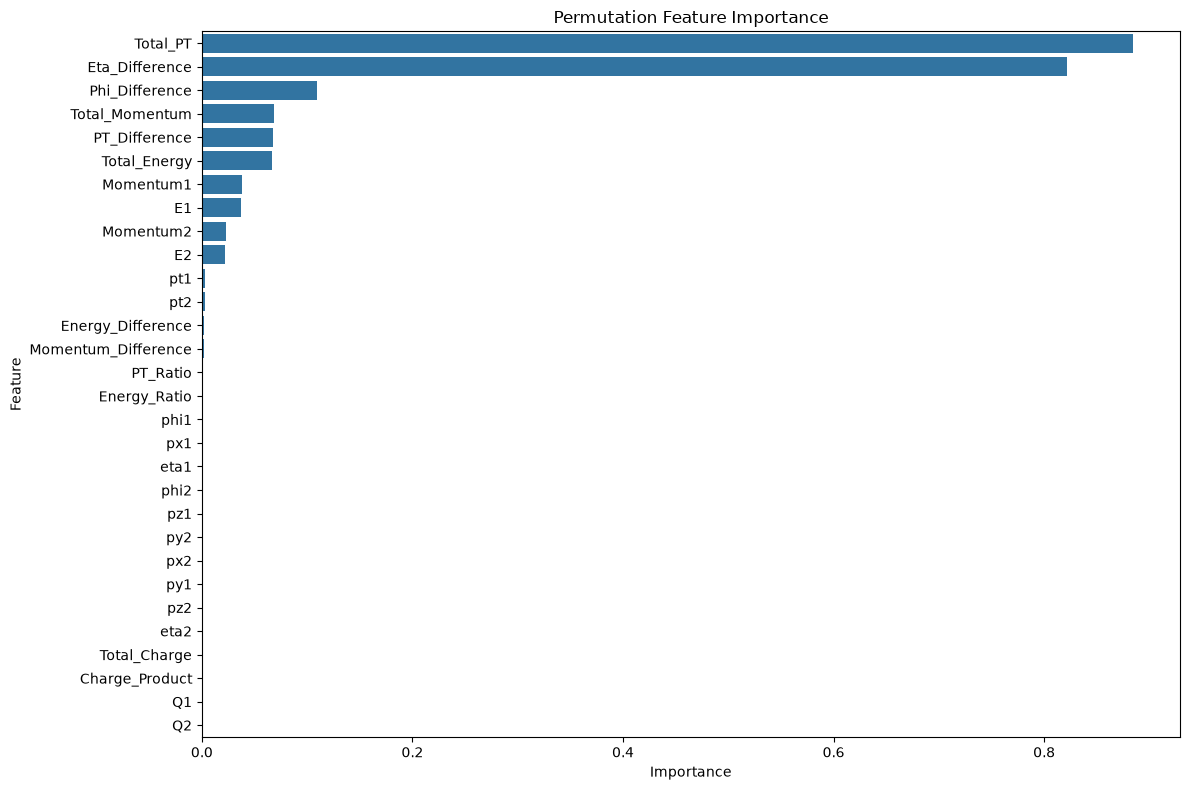

In [ ]:
# =====================================================
# Visualize Permutation Importance
# =====================================================

plt.figure(figsize=(12,8))

sns.barplot(

    data=perm_df,

    y="Feature",

    x="Permutation"

)

plt.title("Permutation Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()